<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/t_SNE_ejemplo_Sencillo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [46]:
# Cargar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Normalizar
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train / Test
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [47]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(4,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    verbose=0
)

print("Accuracy final:", model.evaluate(x_test, y_test, verbose=0)[1])


  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Accuracy final: 0.800000011920929


In [49]:
# Asegurar que el modelo esté construido
model(x_test[:1])

feature_extractor = tf.keras.Model(
    inputs=model.layers[0].input, # Changed from model.input to model.layers[0].input
    outputs=model.layers[-2].output  # penúltima capa
)

features = feature_extractor.predict(x_test)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [50]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=20,
    random_state=42
).fit_transform(features)


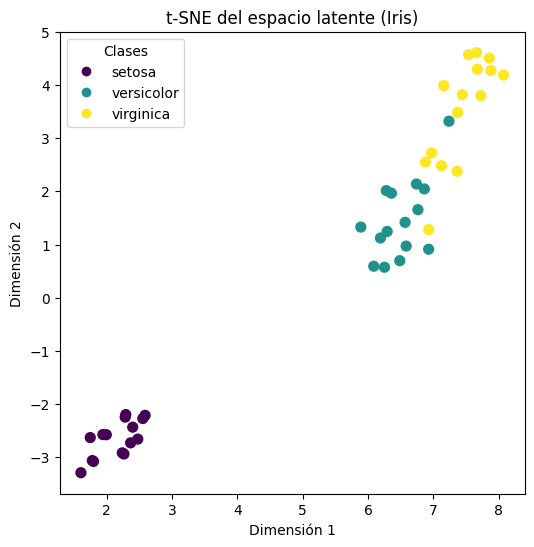

In [51]:
plt.figure(figsize=(6,6))
scatter = plt.scatter(
    tsne[:,0],
    tsne[:,1],
    c=y_test,
    cmap="viridis",
    s=50
)

plt.legend(
    scatter.legend_elements()[0],
    iris.target_names,
    title="Clases"
)

plt.title("t-SNE del espacio latente (Iris)")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.show()


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


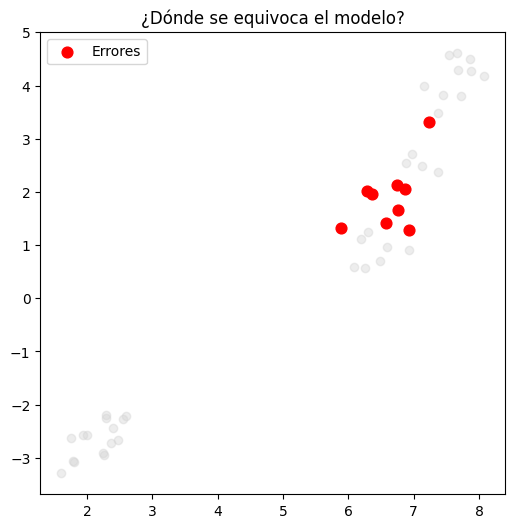

In [52]:
# Predicciones
preds = np.argmax(model.predict(x_test), axis=1)
errors = preds != y_test

plt.figure(figsize=(6,6))

# Todos los puntos
plt.scatter(
    tsne[:,0],
    tsne[:,1],
    c="lightgray",
    alpha=0.4
)

# Errores
plt.scatter(
    tsne[errors,0],
    tsne[errors,1],
    c="red",
    label="Errores",
    s=60
)

plt.legend()
plt.title("¿Dónde se equivoca el modelo?")
plt.show()


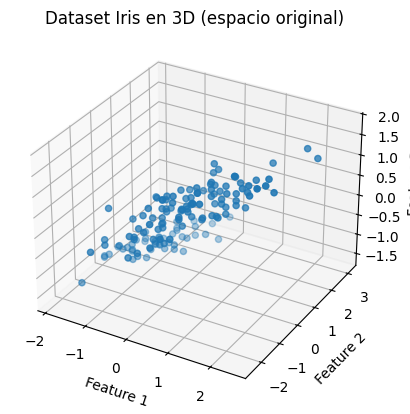

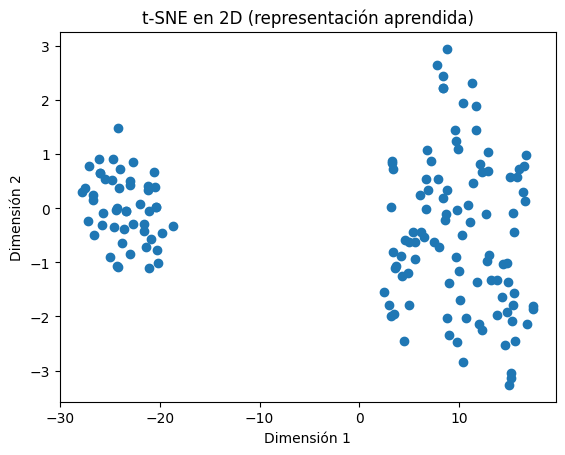

In [53]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

# Cargar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Normalizar
X = StandardScaler().fit_transform(X)

# ====== GRÁFICA 3D (espacio original) ======
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X[:, 0],  # largo del sépalo
    X[:, 1],  # ancho del sépalo
    X[:, 2]   # largo del pétalo
)

ax.set_title("Dataset Iris en 3D (espacio original)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")

plt.show()

# ====== t-SNE a 2D ======
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(X)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1])
plt.title("t-SNE en 2D (representación aprendida)")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.show()


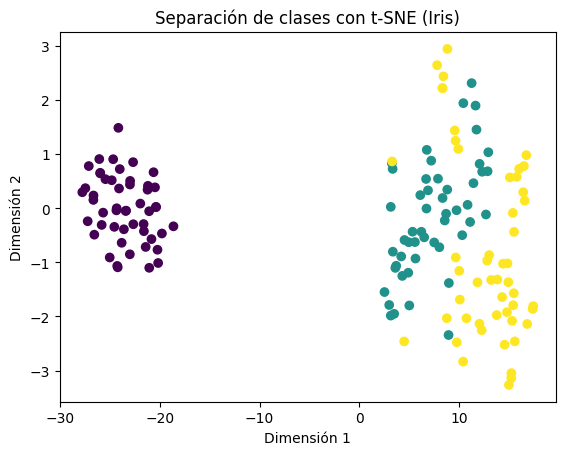

In [54]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Cargar Iris
iris = load_iris()
X = iris.data
y = iris.target

# Normalizar
X = StandardScaler().fit_transform(X)

# t-SNE a 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(X)

# Gráfica con separación de clases
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y)
plt.title("Separación de clases con t-SNE (Iris)")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.show()


In [55]:
tsne_original = TSNE(n_components=2, random_state=42)
X_tsne_original = tsne_original.fit_transform(X)


In [56]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation="relu", input_shape=(4,)),
    tf.keras.layers.Dense(6, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X, y, epochs=50, verbose=0)


  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



In [58]:
# Asegurar que el modelo esté construido
model(X[:1]) # Llamar al modelo con una muestra para construirlo

feature_extractor = tf.keras.Model(
    inputs=model.layers[0].input,
    outputs=model.layers[-2].output
)

features_learned = feature_extractor.predict(X)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [59]:
tsne_learned = TSNE(n_components=2, random_state=42)
X_tsne_learned = tsne_learned.fit_transform(features_learned)


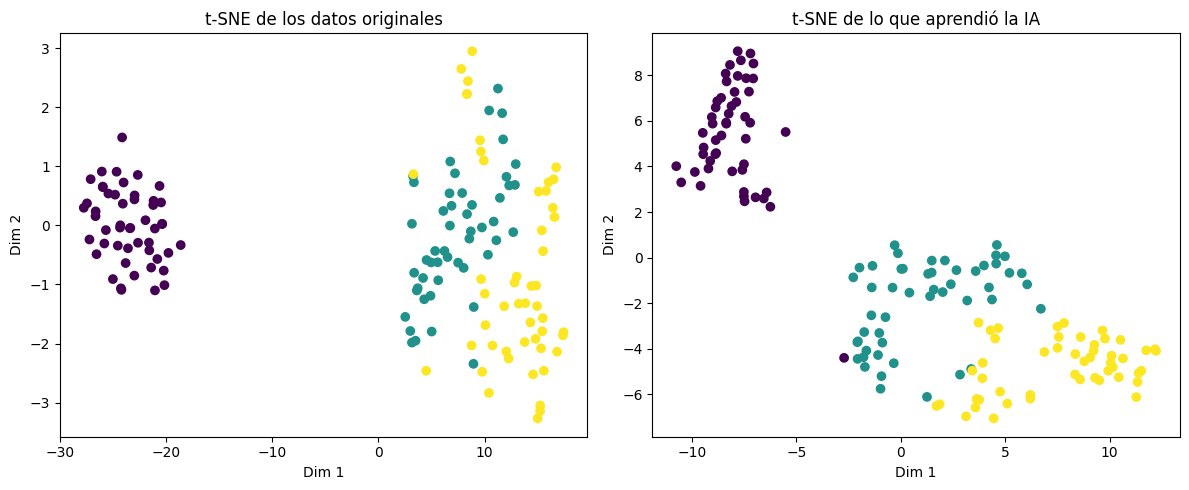

In [60]:
plt.figure(figsize=(12,5))

# Datos originales
plt.subplot(1,2,1)
plt.scatter(X_tsne_original[:,0], X_tsne_original[:,1], c=y)
plt.title("t-SNE de los datos originales")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

# Representación aprendida
plt.subplot(1,2,2)
plt.scatter(X_tsne_learned[:,0], X_tsne_learned[:,1], c=y)
plt.title("t-SNE de lo que aprendió la IA")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.tight_layout()
plt.show()
